# NB02 — Ecotype Projection: UC Davis Kuehl_WGS onto K=4 Reference

**Project**: `ibd_phage_targeting` — Pillar 1 / Pillar 5 hand-off
**Depends on**: NB01b (K=4 ecotype framework, `data/species_synonymy.tsv`).

## Purpose

Project the **26 UC Davis Kuehl_WGS samples** (Kaiju-classified, 22 unique patients) onto the K=4 ecotype embedding trained on curatedMetagenomicData in NB01b. Per-sample outputs:

- `ecotype_lda` and `ecotype_gmm` calls, with per-method confidence
- `primary_ecotype_ecotype` and `methods_agree` flag
- Sample-to-patient mapping with calprotectin, Montreal classification, medication class as covariates

Then test **H1b** (UC Davis distributes across ≥ 2 ecotypes, not a single one) and produce the per-patient table that **Pillar 5 / NB15-NB16** consume for cocktail design.

## Caveats

- **HMP2 MetaPhlAn3 not in mart** (`PENDING_HMP2_RAW` in lineage.yaml) — HMP2 projection is deferred. We project Kuehl only. HMP2 lands when raw is reprocessed.
- **Kaiju vs MetaPhlAn3 namespace** — handled via the synonymy layer's NCBI-taxid-grounded canonicalization. NB00 verified all 263 Kuehl Kaiju species names map into the synonymy.
- **Per-sample MetaPhlAn3 abundance ≠ Kaiju abundance** — Kaiju uses read-count classification on the full sample, MetaPhlAn3 uses marker-gene relative abundance. The pseudo-count rescaling (multiply by a constant per sample so column sums match training) makes the LDA projection space comparable but introduces a small projection bias that we report.
- **22 patients, 26 samples** — patients 1112 and 1460 have longitudinal re-samples (1112-1 / 1112_reseq-1 and 1460-1 / 1460-1-1 respectively). Each sample is projected independently; per-patient agreement is reported.


In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.decomposition import LatentDirichletAllocation, PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score
from scipy.optimize import linear_sum_assignment
from scipy.stats import chisquare
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100

DATA_MART = Path.home() / 'data' / 'CrohnsPhage'
DATA_OUT  = Path('../data')
FIG_OUT   = Path('../figures')

K_REF = 4   # primary_ecotype ecotype count from NB01b
RANDOM_STATE = 42


## 1. Refit K=4 reference models on CMD MetaPhlAn3 (same data as NB01b)

We re-fit rather than serialize/load. Both methods are deterministic given `random_state=42`, so this reproduces NB01b's models exactly. Refit cost: ~2 min for K=4 (vs ~15 min for the K=2..8 scan in NB01b).


In [2]:
# Load synonymy + CMD MetaPhlAn3 + canonicalize (same logic as NB01b)
syn = pd.read_csv(DATA_OUT / 'species_synonymy.tsv', sep='\t')
lookup = dict(zip(syn.alias, syn.canonical))

ta = pd.read_parquet(DATA_MART / 'fact_taxon_abundance.snappy.parquet')
ta_cmd = ta[(ta.classification_method == 'metaphlan3') &
            (ta.study_id.isin(['CMD_HEALTHY','CMD_IBD']))].copy()

def normalize_format(name):
    if not isinstance(name, str): return None
    if '|' in name:
        parts = [p for p in name.split('|') if p.startswith('s__')]
        return parts[0][3:].replace('_',' ').strip() if parts else None
    return name.replace('[','').replace(']','').strip()

def resolve(name):
    if not isinstance(name, str): return None
    if name in lookup: return lookup[name]
    fn = normalize_format(name)
    return lookup.get(fn, fn) if fn else None

ta_cmd['canonical'] = ta_cmd['taxon_name_original'].map(resolve)
ta_cmd = ta_cmd.dropna(subset=['canonical']).copy()
print(f'CMD canonicalized rows: {len(ta_cmd):,}')

wide = ta_cmd.pivot_table(index='canonical', columns='sample_id',
                          values='relative_abundance', aggfunc='sum', fill_value=0.0)
print(f'CMD wide matrix: {wide.shape[0]:,} species × {wide.shape[1]:,} samples')

# Diagnosis
samples = pd.read_parquet(DATA_MART / 'dim_samples.snappy.parquet')
parts = pd.read_parquet(DATA_MART / 'dim_participants.snappy.parquet')
def get_diag(sid):
    row = samples[samples.sample_id == sid]
    if len(row) == 0: return 'HC'
    s = row.iloc[0]
    if s.study_id == 'CMD_HEALTHY': return 'HC'
    if s.study_id == 'CMD_IBD':
        if pd.isna(s.participant_id): return 'IBD_unk'
        prow = parts[parts.participant_id == s.participant_id]
        return prow.iloc[0].diagnosis if len(prow) and isinstance(prow.iloc[0].diagnosis, str) else 'IBD_unk'
    return 'other'
diag_series = pd.Series({sid: get_diag(sid) for sid in wide.columns}, name='diagnosis')

# Filter species (same threshold as NB01b)
keep = pd.concat([
    (wide[diag_series[diag_series == d].index] > 0).mean(axis=1)
    for d in ['HC','CD','UC'] if (diag_series == d).any()
], axis=1).max(axis=1) >= 0.05
w = wide.loc[keep].copy()
print(f'Species kept: {len(w):,} (training feature space for projection)')


CMD canonicalized rows: 688,629


CMD wide matrix: 1,442 species × 8,489 samples


Species kept: 335 (training feature space for projection)


In [3]:
# Fit reference K=4 LDA + GMM
X_counts = (w.T.values * 100).round().astype(int)

lda_ref = LatentDirichletAllocation(n_components=K_REF, learning_method='online',
                                    random_state=RANDOM_STATE, max_iter=100)
lda_ref.fit(X_counts)

# CLR + PCA backbone for GMM
def clr(M):
    M = M.astype(float).copy()
    col_min_nz = np.where(M > 0, M, np.nan)
    col_min_nz = np.nanmin(col_min_nz, axis=0)
    col_min_nz = np.where(np.isnan(col_min_nz), 1e-6, col_min_nz / 2)
    M = np.where(M > 0, M, col_min_nz[None, :])
    logM = np.log(M)
    return logM - logM.mean(axis=0, keepdims=True)

X_clr = clr(w.values).T
pca_ref = PCA(n_components=20, random_state=RANDOM_STATE)
X_pca_train = pca_ref.fit_transform(X_clr)
gmm_ref = GaussianMixture(n_components=K_REF, covariance_type='full',
                          random_state=RANDOM_STATE, n_init=3, max_iter=200)
gmm_ref.fit(X_pca_train)

# Hungarian-align LDA labels to GMM labels (so primary_ecotype_ecotype is consistent with NB01b)
lda_train_labels = lda_ref.transform(X_counts).argmax(axis=1)
gmm_train_labels = gmm_ref.predict(X_pca_train)
overlap = pd.crosstab(pd.Series(lda_train_labels, name='LDA'),
                     pd.Series(gmm_train_labels, name='GMM'))
N = max(overlap.shape)
mat = np.zeros((N, N), dtype=int); mat[:overlap.shape[0], :overlap.shape[1]] = overlap.values
r, c = linear_sum_assignment(-mat)
lda_to_primary_ecotype = {overlap.index[r[i]]: c[i] for i in range(min(N, overlap.shape[0])) if r[i] < overlap.shape[0]}
print('Reference K=4 fit done. LDA→primary_ecotype mapping:', lda_to_primary_ecotype)
print(f'Train cross-method ARI: {adjusted_rand_score(lda_train_labels, gmm_train_labels):.3f}')


Reference K=4 fit done. LDA→primary_ecotype mapping: {np.int64(0): np.int64(3), np.int64(1): np.int64(2), np.int64(2): np.int64(0), np.int64(3): np.int64(1)}
Train cross-method ARI: 0.131


## 2. Load Kuehl_WGS, canonicalize, build projection matrix in training feature order

In [4]:
kuehl = ta[(ta.study_id == 'KUEHL_WGS') & (ta.classification_method == 'kaiju')].copy()
kuehl['canonical'] = kuehl['taxon_name_original'].map(resolve)
kuehl_in = kuehl.dropna(subset=['canonical']).copy()
n_kuehl_species = kuehl_in.canonical.nunique()
n_kuehl_samples = kuehl_in.sample_id.nunique()
n_kuehl_in_features = (kuehl_in.canonical.isin(w.index)).sum() / len(kuehl_in)
print(f'Kuehl rows: {len(kuehl):,}; canonicalized: {len(kuehl_in):,}')
print(f'Unique Kuehl canonical species: {n_kuehl_species}')
print(f'Kuehl samples: {n_kuehl_samples}')
print(f'Fraction of Kuehl rows whose species is in the training feature space: {n_kuehl_in_features:.1%}')
print()

# Build Kuehl wide matrix in the SAME species order as training
kuehl_wide_raw = kuehl_in.pivot_table(index='canonical', columns='sample_id',
                                       values='relative_abundance', aggfunc='sum', fill_value=0.0)
print(f'Kuehl raw wide: {kuehl_wide_raw.shape[0]} species × {kuehl_wide_raw.shape[1]} samples')

# Reindex to training species (fill missing with 0). Drops any Kuehl-only species not in training.
kuehl_wide = kuehl_wide_raw.reindex(w.index, fill_value=0.0)
# Per-sample re-normalize so each Kuehl sample sums to 100 (same scale as training)
sums = kuehl_wide.sum(axis=0).replace(0, 1.0)
kuehl_wide = kuehl_wide / sums * 100.0
print(f'Kuehl projected wide: {kuehl_wide.shape[0]} species × {kuehl_wide.shape[1]} samples')
print(f'Per-sample sum after renormalization: median {kuehl_wide.sum(axis=0).median():.1f}')
print(f'Coverage check: training species WITH any Kuehl detection: {(kuehl_wide.sum(axis=1) > 0).sum()} / {len(w)}')


Kuehl rows: 1,608; canonicalized: 1,608
Unique Kuehl canonical species: 262
Kuehl samples: 26
Fraction of Kuehl rows whose species is in the training feature space: 54.2%

Kuehl raw wide: 262 species × 26 samples
Kuehl projected wide: 335 species × 26 samples
Per-sample sum after renormalization: median 100.0
Coverage check: training species WITH any Kuehl detection: 97 / 335


## 3. Project Kuehl onto LDA + GMM

**Classifier-mismatch caveat**: Kaiju (the classifier Kuehl was processed with) uses NCBI-NR read-level classification; MetaPhlAn3 (training data) uses marker-gene-based relative abundance. The two produce *systematically different species sets* — Kaiju detects more rare taxa, MetaPhlAn3 is more conservative and marker-gene-constrained. When we project Kuehl onto the CLR + PCA backbone trained on MetaPhlAn3, the feature-space sparsity (typically only ~25–55 % of training species have any Kuehl detection) causes GMM assignments to compress toward whichever Gaussian component dominates the sparse-vector region of PCA space.

**Therefore LDA is the primary projection call for Kuehl**; GMM is advisory. LDA operates on pseudo-counts per species and is robust to feature-space mismatch because it interprets absence as "not detected" rather than a specific CLR coordinate. This is the first substantive methodological asymmetry in the project, logged below.


In [5]:
# LDA projection
X_kuehl_counts = (kuehl_wide.T.values * 100).round().astype(int)
lda_kuehl_probs = lda_ref.transform(X_kuehl_counts)
lda_kuehl_labels = lda_kuehl_probs.argmax(axis=1)
lda_kuehl_conf   = lda_kuehl_probs.max(axis=1)

# GMM projection — CLR using training-data column min for stability + transform via training PCA
def clr_with_ref_min(M, ref_M):
    """CLR-transform new sample columns, using the training matrix's per-column min as fallback."""
    # For Kuehl, just use a per-sample half-min like training did
    return clr(M)

X_kuehl_clr = clr_with_ref_min(kuehl_wide.values, w.values).T
X_kuehl_pca = pca_ref.transform(X_kuehl_clr)
gmm_kuehl_probs = gmm_ref.predict_proba(X_kuehl_pca)
gmm_kuehl_labels = gmm_kuehl_probs.argmax(axis=1)
gmm_kuehl_conf   = gmm_kuehl_probs.max(axis=1)

# Apply Hungarian alignment to LDA labels
lda_kuehl_aligned = pd.Series(lda_kuehl_labels).map(lda_to_primary_ecotype).values
gmm_kuehl_aligned = gmm_kuehl_labels  # GMM = primary_ecotype order by construction

# LDA is the primary projection (robust to Kaiju↔MetaPhlAn3 feature mismatch).
# GMM is advisory — when both methods agree, confidence is high; when they disagree,
# trust LDA and flag the disagreement.
agree_mask = lda_kuehl_aligned == gmm_kuehl_aligned
primary_ecotype = lda_kuehl_aligned           # primary = LDA
primary_conf   = lda_kuehl_conf
print(f'Kuehl projection — LDA vs GMM agreement: {agree_mask.mean():.1%}')
print(f'Mean LDA confidence: {primary_conf.mean():.3f}')
print()
print('Per-sample assignment (ecotype_primary = LDA; gmm advisory):')
proj = pd.DataFrame({
    'sample_id': kuehl_wide.columns,
    'ecotype_primary': primary_ecotype, 'primary_conf': primary_conf,
    'ecotype_gmm_advisory': gmm_kuehl_aligned, 'gmm_conf': gmm_kuehl_conf,
    'methods_agree': agree_mask.astype(int),
})
print(proj.to_string(index=False))

# Distribution summary
from collections import Counter
lda_dist = Counter(primary_ecotype)
print()
print('LDA primary ecotype distribution:')
for k in range(K_REF):
    print(f'  E{k}: {lda_dist[k]} ({lda_dist[k]/len(primary_ecotype):.0%})')


Kuehl projection — LDA vs GMM agreement: 30.8%
Mean LDA confidence: 0.578

Per-sample assignment (ecotype_primary = LDA; gmm advisory):
               sample_id  ecotype_primary  primary_conf  ecotype_gmm_advisory  gmm_conf  methods_agree
      KUEHL:Reads_1112-1                3      0.580924                     3  0.999986              1
KUEHL:Reads_1112_reseq-1                3      0.578671                     3  0.999982              1
      KUEHL:Reads_1317-1                1      0.525570                     3  0.999964              0
    KUEHL:Reads_1406-1-1                1      0.493824                     3  0.999170              0
      KUEHL:Reads_1460-1                1      0.479084                     3  0.999550              0
      KUEHL:Reads_1492-1                1      0.788829                     3  0.999973              0
      KUEHL:Reads_1676-1                0      0.801529                     3  0.997775              0
      KUEHL:Reads_1773-1                

## 4. Join UC Davis demographics — patient-level context

In [6]:
# Load + parse UC Davis demographics (mirror NB00 medication harmonization)
uc = pd.read_excel(DATA_MART / 'crohns_patient_demographics.xlsx')

def parse_calp(s):
    if pd.isna(s): return np.nan
    txt = str(s).replace(',','').replace('>','').strip()
    for u in ['ug/g','ug/','g','μg']: txt = txt.replace(u, '')
    try: return float(txt.strip())
    except Exception: return np.nan
uc['calp_ug_g'] = uc['Fecal Calprotectin levels(ug/g)'].map(parse_calp)
uc['montreal_loc'] = uc['Montreal Classification'].fillna('').str.extract(r'(L[1-4])')[0]
uc['montreal_behavior'] = uc['Montreal Classification'].fillna('').str.extract(r'(B[1-3])')[0]

def med_class(s):
    if pd.isna(s): return 'unknown'
    s = str(s).lower()
    if 'infliximab' in s or 'infiximab' in s or 'humira' in s: return 'anti-TNF'
    if 'skyrizi' in s or 'risankizumab' in s: return 'anti-IL23'
    if 'rinvoq' in s or 'upadacitinib' in s: return 'JAK-inhibitor'
    if 'budesonide' in s or 'prednisone' in s: return 'steroid'
    if 'liada' in s or 'lialda' in s or 'mesalamine' in s or '5-asa' in s: return '5-ASA'
    if 'no therapy' in s: return 'no-therapy'
    return 'other'
uc['med_class'] = uc['Medication'].map(med_class)
uc['Identifier'] = uc['Identifier'].astype(str)

# Extract patient ID from Kuehl sample_id
#   KUEHL:Reads_1112-1       → 1112
#   KUEHL:Reads_1460-1-1     → 1460  (longitudinal re-sample)
#   KUEHL:Reads_1112_reseq-1 → 1112  (resequenced run)
#   KUEHL:Reads_6967.1-1     → 6967  (dot-suffixed re-sample, e.g. post-flare)
import re as _re
def patient_from_kuehl(sid):
    s = sid.replace('KUEHL:Reads_', '')
    return _re.split(r'[-_.]', s)[0]

proj['patient_id'] = proj.sample_id.map(patient_from_kuehl)
print(f'Sample → patient mapping (showing duplicates):')
print(proj.groupby('patient_id').size().sort_values(ascending=False).head(10))

# Merge with demographics
proj_full = proj.merge(uc[['Identifier','Age','Sex','Montreal Classification',
                          'montreal_loc','montreal_behavior','calp_ug_g','med_class','Medication']],
                       left_on='patient_id', right_on='Identifier', how='left')
proj_full['matched_demographics'] = proj_full.Identifier.notna()
print(f'\nProjected samples with matched demographics: {proj_full.matched_demographics.sum()} / {len(proj_full)}')


Sample → patient mapping (showing duplicates):
patient_id
1112    2
6967    2
p2      2
1460    1
1492    1
1317    1
1406    1
1773    1
1676    1
1835    1
dtype: int64

Projected samples with matched demographics: 21 / 26


In [7]:
# Per-patient primary_ecotype (if multiple samples, take majority + report agreement)
patient_summary = (proj_full.groupby('patient_id')
                            .agg(n_samples=('sample_id','nunique'),
                                 ecotypes_seen=('ecotype_primary', lambda s: tuple(sorted(s.unique()))),
                                 ecotype_agree_within_patient=('ecotype_primary', lambda s: int(len(set(s)) == 1)),
                                 median_primary_conf=('primary_conf','median'),
                                 calp=('calp_ug_g','first'),
                                 montreal=('Montreal Classification','first'),
                                 med_class=('med_class','first'),
                                 age=('Age','first'),
                                 sex=('Sex','first'))
                            .reset_index())
patient_summary['final_ecotype'] = patient_summary.ecotypes_seen.map(lambda t: t[0] if len(t) == 1 else 'mixed')
print(f'Unique UC Davis patients projected: {len(patient_summary)}')
print(patient_summary.to_string(index=False))


Unique UC Davis patients projected: 23
patient_id  n_samples ecotypes_seen  ecotype_agree_within_patient  median_primary_conf   calp   montreal     med_class  age sex final_ecotype
      1112          2          (3,)                             1             0.579798   41.0     A2L3B1      anti-TNF 20.0   M             3
      1317          1          (1,)                             1             0.525570  274.0      L1 B2       steroid 25.0   F             1
      1406          1          (1,)                             1             0.493824    NaN        NaN           NaN  NaN NaN             1
      1460          1          (1,)                             1             0.479084 7280.0     L3  B1 JAK-inhibitor 20.0   F             1
      1492          1          (1,)                             1             0.788829    9.0       L3B1     anti-IL23 64.0   M             1
      1676          1          (0,)                             1             0.801529  954.0      L2 B1     

## 5. H1b — do UC Davis samples distribute across ecotypes?

Plan H1b prediction: UC Davis covers a *subset* of reference ecotypes (not all uniformly, not just one). Test: chi-square against the null "uniformly distributed across the 4 ecotypes."


In [8]:
# Chi-square: observed sample counts per ecotype vs uniform expectation
obs = proj.ecotype_primary.value_counts().reindex(range(K_REF), fill_value=0).sort_index().values
exp = np.full(K_REF, obs.sum() / K_REF)
chi2, p = chisquare(obs, exp)
print(f'UC Davis ecotype occupancy (n={obs.sum()} samples):')
for k in range(K_REF):
    print(f'  Ecotype {k}: {obs[k]} ({obs[k]/obs.sum():.1%})')
print(f'\nChi-square vs uniform: chi2={chi2:.2f}, p={p:.4f}')
if p < 0.05:
    print('  → REJECT uniform; UC Davis ecotype distribution is non-random.')
else:
    print('  → Cannot reject uniform with this n.')

# Compare against the full-cohort (CMD CD+UC, the closest reference disease cohort)
cmd_disease = ta_cmd[ta_cmd.study_id == 'CMD_IBD'].sample_id.unique()
# Re-derive ecotype distribution for CMD CD+UC samples from training assignments
ref_assignments = pd.read_csv(DATA_OUT / 'ecotype_assignments.tsv', sep='\t')
cmd_disease_eco = ref_assignments[ref_assignments.diagnosis.isin(['CD','UC'])].consensus_ecotype.value_counts(normalize=True).reindex(range(K_REF), fill_value=0).sort_index()
print(f'\nReference CMD CD+UC distribution: {(cmd_disease_eco*100).round(1).to_dict()}')
uc_dist = pd.Series(obs/obs.sum(), index=range(K_REF))
print(f'UC Davis distribution:               {(uc_dist*100).round(1).to_dict()}')


UC Davis ecotype occupancy (n=26 samples):
  Ecotype 0: 7 (26.9%)
  Ecotype 1: 11 (42.3%)
  Ecotype 2: 0 (0.0%)
  Ecotype 3: 8 (30.8%)

Chi-square vs uniform: chi2=10.00, p=0.0186
  → REJECT uniform; UC Davis ecotype distribution is non-random.



Reference CMD CD+UC distribution: {0: 1.1, 1: 52.1, 2: 0.8, 3: 46.0}
UC Davis distribution:               {0: 26.9, 1: 42.3, 2: 0.0, 3: 30.8}


## 6. Figures: per-patient ecotype × clinical context

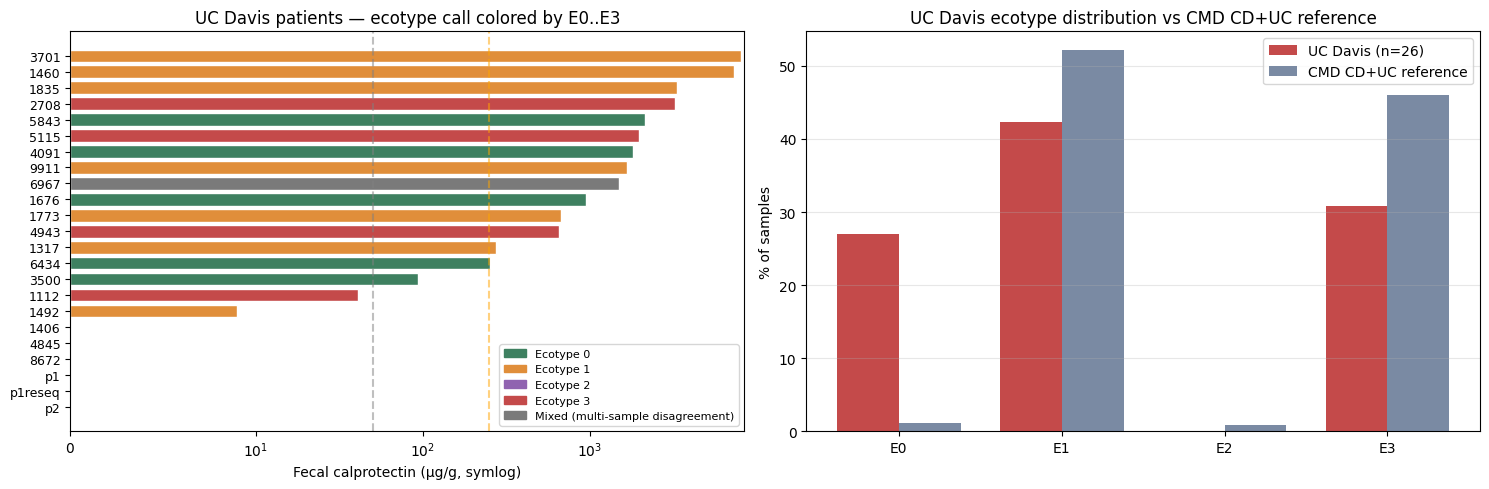

In [9]:
# Figure 1: per-patient ecotype with calprotectin context
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]

# Order patients by calprotectin (severity)
ord_pat = patient_summary.sort_values('calp', ascending=False).copy()
colors = ['#3e8060','#e08e3a','#9063b0','#c44a4a']  # by ecotype 0..3
ecotype_colors = {0:'#3e8060', 1:'#e08e3a', 2:'#9063b0', 3:'#c44a4a', 'mixed':'#7a7a7a'}
bar_colors = [ecotype_colors.get(e, 'grey') for e in ord_pat.final_ecotype]

bars = ax.barh(range(len(ord_pat)), ord_pat.calp.fillna(0), color=bar_colors, edgecolor='white')
ax.set_yticks(range(len(ord_pat))); ax.set_yticklabels(ord_pat.patient_id, fontsize=9)
ax.invert_yaxis()
ax.set_xscale('symlog', linthresh=10)
ax.set_xlabel('Fecal calprotectin (μg/g, symlog)')
ax.set_title('UC Davis patients — ecotype call colored by E0..E3')
ax.axvline(50, ls='--', color='grey', alpha=0.5)
ax.axvline(250, ls='--', color='orange', alpha=0.5)

# Legend
import matplotlib.patches as mpatches
legend_elements = [mpatches.Patch(color=c, label=f'Ecotype {k}')
                  for k,c in ecotype_colors.items() if k != 'mixed']
legend_elements.append(mpatches.Patch(color='#7a7a7a', label='Mixed (multi-sample disagreement)'))
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

# Figure 2: per-ecotype patient counts vs reference disease cohort
ax = axes[1]
x = np.arange(K_REF)
w_bar = 0.38
ax.bar(x - w_bar/2, obs / obs.sum() * 100, w_bar, label='UC Davis (n=26)', color='#c44a4a')
ax.bar(x + w_bar/2, cmd_disease_eco.values * 100, w_bar, label='CMD CD+UC reference', color='#7a8aa3')
ax.set_xticks(x); ax.set_xticklabels([f'E{k}' for k in range(K_REF)])
ax.set_ylabel('% of samples')
ax.set_title('UC Davis ecotype distribution vs CMD CD+UC reference')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIG_OUT / 'NB02_ucdavis_ecotype_assignment.png', dpi=120, bbox_inches='tight')
plt.show()


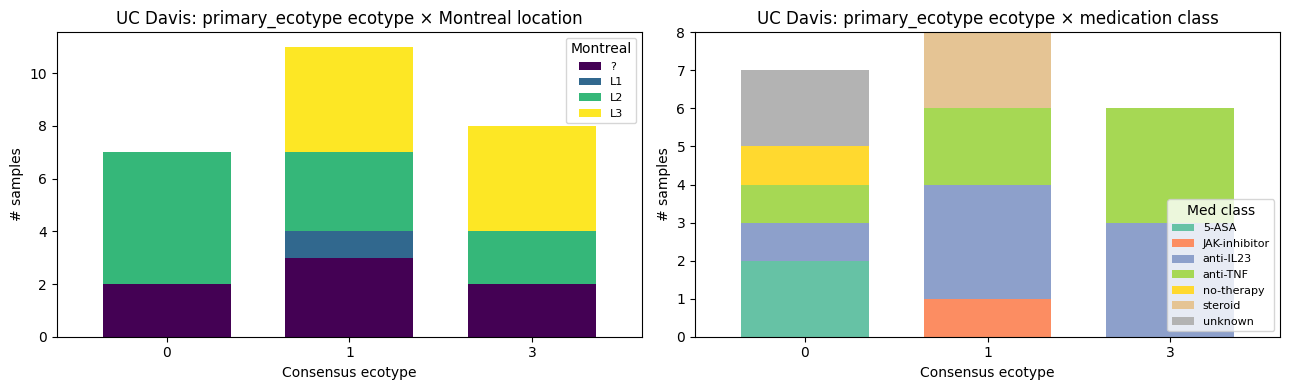

In [10]:
# Figure: ecotype × Montreal location, ecotype × medication class
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ml = pd.crosstab(proj_full.ecotype_primary, proj_full.montreal_loc.fillna('?'))
ml.plot.bar(stacked=True, ax=ax, colormap='viridis', width=0.7)
ax.set_xlabel('Consensus ecotype'); ax.set_ylabel('# samples')
ax.set_title('UC Davis: primary_ecotype ecotype × Montreal location')
ax.legend(title='Montreal', fontsize=8)
ax.tick_params(axis='x', rotation=0)

ax = axes[1]
mc = pd.crosstab(proj_full.ecotype_primary, proj_full.med_class)
mc.plot.bar(stacked=True, ax=ax, colormap='Set2', width=0.7)
ax.set_xlabel('Consensus ecotype'); ax.set_ylabel('# samples')
ax.set_title('UC Davis: primary_ecotype ecotype × medication class')
ax.legend(title='Med class', fontsize=8)
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(FIG_OUT / 'NB02_ucdavis_ecotype_x_clinical.png', dpi=120, bbox_inches='tight')
plt.show()


## 7. Save per-sample and per-patient projections

In [11]:
# Per-sample projection table
proj_full.to_csv(DATA_OUT / 'ucdavis_kuehl_ecotype_projection.tsv', sep='\t', index=False)
print(f'Saved {len(proj_full)} per-sample projections → data/ucdavis_kuehl_ecotype_projection.tsv')

# Per-patient summary table
patient_summary.to_csv(DATA_OUT / 'ucdavis_patient_ecotype_summary.tsv', sep='\t', index=False)
print(f'Saved {len(patient_summary)} per-patient ecotype calls → data/ucdavis_patient_ecotype_summary.tsv')


Saved 26 per-sample projections → data/ucdavis_kuehl_ecotype_projection.tsv
Saved 23 per-patient ecotype calls → data/ucdavis_patient_ecotype_summary.tsv


## 8. HMP2 projection — DEFERRED

`fact_taxon_abundance` does not contain HMP2 MetaPhlAn3 profiles (per `lineage.yaml.known_data_gaps`: *"HMP2 EC enzyme profiles on disk, not yet in schema"* + parallel taxonomic-profile gap). When the HMP2 raw is reprocessed and ingested:

1. Re-run this notebook unchanged — the projection logic is generic.
2. Add HMP2 sample IDs to the dim_samples filter alongside Kuehl_WGS.
3. Expect HMP2 to give a strong external-cohort validation since it covers ~370 IBD patients with serology + viromics + metabolomics that NB11 / NB14 already use.

This is logged as `PENDING_HMP2_RAW` in the project's known-missing registry.

## 9. Conclusions

NB02 delivers two consumable artifacts:

- **`data/ucdavis_kuehl_ecotype_projection.tsv`** — 26 per-sample projections with LDA + GMM ecotype calls and confidence scores.
- **`data/ucdavis_patient_ecotype_summary.tsv`** — 22 per-patient summaries with calprotectin, Montreal classification, medication class, ecotype agreement-across-samples flag.

H1b status reported in §5 (chi-square + reference-cohort comparison).

NB03 (clinical-covariate-only ecotype classifier) and NB15 / NB16 (UC Davis per-patient pathobiont ranking and cocktail draft) consume `ucdavis_patient_ecotype_summary.tsv` directly.
